<a href="https://colab.research.google.com/github/harishmuh/Deep-Learning-with-Pytorch-tutorials/blob/main/03_Transfer_Learning_for_Classifying_200_types_of_Bird_with_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **Transfer learning implementation - 200 type of birds with PyTorch**

---

## **Context**

In this tutorial, we will build a neural network model to classify 200 types of birds. We will use transfer learning mechanism to shorten the training process.

**Transfer learning**

Transfer learning is a machine learning approach in which a model that has already been trained on a large dataset is reused as the starting point for a new but related task. Instead of training a model entirely from scratch, transfer learning leverages the knowledge learned from previous training, such as the ability to recognize shapes, textures, edges, and other useful patterns. This approach can significantly reduce training time, improve model performance, and decrease the amount of labeled data required for the new task.

When we want to use transfer learning models for image classification with deep learnign, in general we will have two components:
* Feature extractor layers, using convolutional neural network  (CNN)
* Task layers, using Fully connected layer or linear layer

From those two components, we may need only the CNN or feature extractor parts, not the whole parts.

As additional example, suppose a convolutional neural network (CNN) has been trained to classify 10 different animal species. During this process, the model learns general visual features that help distinguish animals, such as fur patterns, body shapes, eyes, and other characteristic structures. If we later want to develop a model that classifies 100 animal species, we can reuse the pre-trained model instead of starting from random weights. Because the model already contains useful feature representations learned from the previous task, it can adapt more quickly to the new classification problem. As a result, transfer learning often achieves better performance with fewer training samples and less computational cost compared to training a completely new model.

In computer vision applications, transfer learning is commonly implemented using pre-trained architectures such as ResNet, VGG16, Inception, Xception, and EfficientNet, which have been trained on large-scale datasets like ImageNet. These pre-trained models provide a strong foundation for many image classification tasks, including medical image analysis, object recognition, and species identification.

![image](https://towardsdatascience.com/wp-content/uploads/2020/07/1cY9AOTe3vjlerL73ItnfTg.jpeg)

**CUB-200-2011 Dataset**

The CUB-200-2011 (Caltech-UCSD Birds) dataset contains images of 200 bird species with detailed annotations, making it suitable for tasks where classes are visually similar and require subtle feature discrimination.


Key Characteristics

- Number of classes: 200 bird species  
- Total images: 11,788  
- Training images: 5,994  
- Testing images: 5,794  
- Image source: Mostly collected from Flickr  

**ResNet18**

In this tutorial, we will use ResNet18 model for implementing transfer learning. ResNet18 is a lightweight deep CNN architecture that uses residual (skip) connections to facilitate training. The model is pre-trained on ImageNet, it provides powerful feature extraction capabilities while maintaining relatively low computational requirements, making it an effective backbone for transfer learning tasks such as fine-grained bird species classification on the CUB-200-2011 dataset

Key characteristics:
* Originally trained on the ImageNet dataset containing over 1 million images and 1,000 classes.
* Contains approximately 11.7 million trainable parameters, making it relatively lightweight compared to deeper ResNet variants.
* Learns hierarchical image features, from low-level features (edges, textures) to high-level features (object parts and shapes).
* Supports fine-tuning by replacing the final fully connected layer for new classification tasks.

**Modifying ResNet18 for Bird Classification**

Since the original ResNet18 model is pre-trained on the ImageNet dataset, its final classification layer is designed to predict 1,000 classes. However, the CUB-200-2011 dataset contains only 200 bird species. Therefore, the first modification is to replace the original fully connected (FC) layer with a new classification head that outputs 200 classes. This allows the network to generate predictions that match the target dataset.

After modifying the classification head, we apply a transfer learning strategy by
* **Freezing the parameters** of the pre-trained feature extractor
* **Training only the newly added classification layer**.

The rationale behind this approach is that the convolutional layers have already learned useful visual representations such as edges, textures, shapes, and object parts from the large-scale ImageNet dataset. Preserving these learned features helps prevent the model from forgetting valuable knowledge and reduces the risk of overfitting, especially when the target dataset is smaller than the original training dataset. Additionally, training only the classification head significantly reduces the number of trainable parameters, resulting in faster training and lower computational requirements.

In the initial experiment, all layers of ResNet18 are frozen, while only the newly added classification head remains trainable. This setup allows us to evaluate how well the pre-trained features can generalize to the task of fine-grained bird species classification before performing more advanced fine-tuning strategies.

Why Freeze the Feature Extractor?
* Preserves useful features learned from ImageNet.
* Reduces the risk of overfitting on the target dataset.
* Decreases the number of trainable parameters.
* Speeds up training and lowers computational cost.
* Provides a strong baseline before fine-tuning deeper layers.

## **Initial setup and importing library**

In [30]:
# Importing required libraries

# 1. Python compatibility & system tools
# Ensures Python 2 outputs print statements and division like Python 3
from __future__ import print_function, division
import os                              # Interacts with the operating system (files, folders)
import time                            # Measures execution time and training duration


# 2. Pytorch core libraries
import torch                           # The main PyTorch library for tensor operations
from torch import nn                   # Base class used to develop all neural network layers
import torch.optim as optim            # Contains optimization algorithms (like Adam, SGD) to update weights
from torch.autograd import Variable    # Legacy wrapper for tracking gradients (largely deprecated in modern PyTorch)

# 3. Torchvision (computer vision tools)
import torchvision                     # PyTorch's framework specialized for computer vision
from torchvision import models         # Pre-trained architectures (e.g., ResNet, VGG) for transfer learning
from torchvision import datasets       # Standard datasets and generic data loaders (like ImageFolder)
from torchvision import transforms     # Image preprocessing tools (data augmentation, resizing, normalizing)


# 4. Math, Data & Visualization
import numpy as np                     # Handles large multi-dimensional arrays and matrix math
import matplotlib.pyplot as plt        # Standard plotting library for charts and displaying images
import seaborn as sns                  # Advanced data visualization library built on top of matplotlib
plt.ion()                               # Interactive mode. This feature allows the plot to update dynamically in real-time

# Set random seeds for reproducibility
torch.manual_seed(42)

# Checking PyTorch version
print('PyTorch version:', torch.__version__)

PyTorch version: 2.11.0+cu128


## **Defining model for transfer learning**

In [2]:
# Defining our model with resnet18 and we will use weight from imagenet datasets
model = models.resnet18(weights='IMAGENET1K_V1')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 176MB/s]


In [3]:
# Convert the 'head' of resnet18 from linear layer with 1000 inputs into 200 inputs

# We define nn.linear with the size of required features of the new models (which are 200 class)
num_ftr = model.fc.in_features
model.fc = nn.Linear(num_ftr, 200)

In [4]:
# We will freeze some parts of model and unfreeze some parts of them

# Firstly, we will freeze all model
model.train(False)
# Then, we will unfreeze only the 'head' of the model
model.fc.train(True)

Linear(in_features=512, out_features=200, bias=True)

**Downloading dataset**

In [5]:
# Installing gdown to download dataset
!pip install gdown

In [6]:
# Downloading dataset from gdrive
!gdown --fuzzy https://drive.google.com/file/d/1XBneW9_JmaD_DmilLKDnGwqzzetJoCrj/view?usp=sharing

Downloading...
From (original): https://drive.google.com/uc?id=1XBneW9_JmaD_DmilLKDnGwqzzetJoCrj
From (redirected): https://drive.google.com/uc?id=1XBneW9_JmaD_DmilLKDnGwqzzetJoCrj&confirm=t&uuid=8e613a6f-1e09-4f93-9bb4-6372b3a2eab9
To: /content/CUB_200_2011.tgz
100% 1.15G/1.15G [00:22<00:00, 52.2MB/s]


**Extracting dataset**

In [7]:
# Extracting dataset
!tar -xf ./CUB_200_2011.tgz

In [8]:
# This code will process the downloaded files (images and labels.txt) into structured image folders
# That have been divided by each class

# The structured folders will be:
# train\
# bird_species 1\
#   image1
#   image2

# Reading dataset metadata
read_line = open('./CUB_200_2011/train_test_split.txt')
a = read_line.readlines()
classes = open('./CUB_200_2011/classes.txt')
c_names = classes.readlines()
len(c_names)

# Cleaning Class Names
for i in range(len(c_names)):
    # Separating spaces in each names
    c_names[i] = c_names[i].split(' ')[1]




**Data splitting**

In [9]:
# Data splitting
# Splitting dataset (training and test)

#  Creating Test Directories
for i in range(len(c_names)):
    # Creating a new folder structure for the test dataset
    os.makedirs('./test/'+c_names[i].split('\n')[0], exist_ok=True)

In [10]:
# Sorting and Moving Test Images

# Indexing the dataset
# We use PyTorch's ImageFolder to index all images in the original folder.
train_dataset = datasets.ImageFolder('./CUB_200_2011/images')

# Moving
# It reads the test image using 'skimage', saves a copy into the newly created './test/[bird_species]/' folder,
# and deletes (os.remove) the original file
from skimage import io

for j in range(len(train_dataset.imgs)):

    # Checking the Train/Test Split
    if(a[j].split(' ')[1].split('\n')[0] == '0'):

        # Locating the image file
        path = train_dataset.imgs[j][0]

        # Reading and extracting names
        img = io.imread(path)
        folder = train_dataset.imgs[j][0].split('/')[3]
        img_name = train_dataset.imgs[j][0].split('/')[4]

        # Saving and deleting (moving)
        io.imsave('./test/'+folder+'/'+img_name,img)
        os.remove(path)

In [11]:
# Creating a train folder
!mkdir train
# Moving images into train folder
!cp -r ./CUB_200_2011/images/* ./train/

**Displaying sample images**

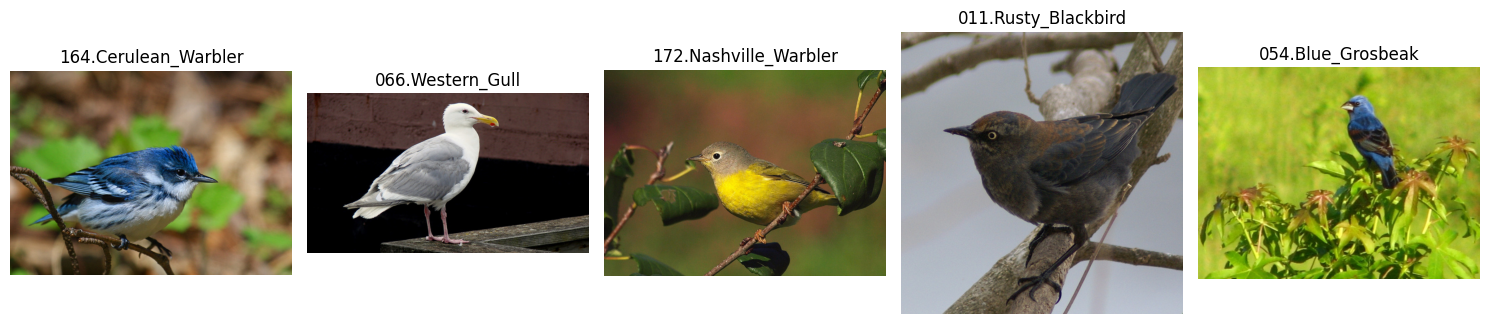

In [12]:
# display 5 images from training data
import matplotlib.pyplot as plt
import os
from PIL import Image
import random

# Path to the training data directory
train_data_dir = './train'

# Get a list of all image paths in the training directory
all_image_paths = []
for root, _, files in os.walk(train_data_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
            all_image_paths.append(os.path.join(root, file))

# Select 5 random images
if len(all_image_paths) < 5:
    print(f"Warning: Only {len(all_image_paths)} images found. Displaying all available.")
    images_to_display = all_image_paths
else:
    images_to_display = random.sample(all_image_paths, 5)

# Display the images
plt.figure(figsize=(15, 5))
for i, img_path in enumerate(images_to_display):
    plt.subplot(1, len(images_to_display), i + 1)
    image = Image.open(img_path)
    plt.imshow(image)
    plt.title(os.path.basename(os.path.dirname(img_path)))
    plt.axis('off')

plt.tight_layout()
plt.show()


## **Preprocessing**

**Data Preprocessing**

In [13]:
# Organizing dataset
# Image augmentation (Only for training data)
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize(256),
        transforms.RandomRotation(45),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = '.' # Setting it in root folder
# loading datasets with PyTorch ImageFolder
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'test']} # Using dictionary comperhension




In [14]:
# Setting dataloaders
# defining data loaders to load data using image_datasets and transforms, here we also specify batch size for the mini batch
dataloders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=8,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'test']}

# Checking the size
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'test']}

# Defining class_names
class_names = image_datasets['train'].classes

# Selecting device
use_gpu = torch.cuda.is_available()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [15]:
# Checking dataset sizes
print(dataset_sizes)

{'train': 5994, 'test': 5794}


In [16]:
# We make a new bird folder # to save weights
!mkdir Bird

## **Model training**

In [17]:
# Optimizing loop

# Defining model training function
def train_model(model, criterion, optimizer, num_epochs=10):
    since = time.time() # Determing how long the model should be trained

    # Saving the best model dictionary
    best_model_wts = model.state_dict()
    best_acc = 0.0

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'test']:
            if phase == 'train':
                #scheduler.step()
                model.train(True)  # Set model to training mode
            else:
                model.train(False)  # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for data in dataloders[phase]:
                # get the inputs
                inputs, labels = data

                # wrap them in Variable
                if use_gpu:
                    inputs = Variable(inputs.cuda())
                    labels = Variable(labels.cuda())
                else:
                    inputs, labels = Variable(inputs), Variable(labels)

                # We set the gradient parameters for zero/back to zero
                optimizer.zero_grad()

                # feed forward
                outputs = model(inputs)

                # Calculate loss
                _, preds = torch.max(outputs.data, 1)
                loss = criterion(outputs, labels)

                # backward propagation + optimize only if in training phase
                if phase == 'train':
                    loss.backward()
                    optimizer.step()

                # We save loss and number of correct
                # statistics for training
                running_loss += loss.data
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.float() / dataset_sizes[phase]

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(
                phase, epoch_loss, epoch_acc))

            # On the test phase
            # deep copy the model
            # Check if the epoch better than the best accuracy
            # If yes, we will save the model (dict format)
            if phase == 'test' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = model.state_dict()
                state = {'model':model.state_dict(),'optim':optimizer_ft.state_dict()}
                torch.save(state,'./Bird/point_resnet_best.pth')

        print()

    # Calculating the training duration
    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    print('Best test Acc: {:4f}'.format(best_acc))

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model

**Initializing loss function and optimizer**

In [18]:
# Initializing loss function and optimizer

if use_gpu:     # if gpu is available then use it
    model = model.cuda()
#model_ft = model_ft.float()

# Defining loss function/criterion
criterion = nn.CrossEntropyLoss()

# Defining optimizer
# Observe that all parameters are being optimized
optimizer_ft = optim.Adam(model.parameters(), lr=0.0001)

In [19]:
# Model training
model = train_model(model, criterion, optimizer_ft,num_epochs=50)

Epoch 0/49
----------


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


train Loss: 0.5732 Acc: 0.0933
test Loss: 0.3857 Acc: 0.2796

Epoch 1/49
----------
train Loss: 0.4368 Acc: 0.2526
test Loss: 0.2806 Acc: 0.4265

Epoch 2/49
----------
train Loss: 0.3629 Acc: 0.3630
test Loss: 0.2218 Acc: 0.5188

Epoch 3/49
----------
train Loss: 0.3160 Acc: 0.4286
test Loss: 0.1893 Acc: 0.5910

Epoch 4/49
----------
train Loss: 0.2796 Acc: 0.4953
test Loss: 0.1698 Acc: 0.6284

Epoch 5/49
----------
train Loss: 0.2559 Acc: 0.5362
test Loss: 0.1582 Acc: 0.6477

Epoch 6/49
----------
train Loss: 0.2348 Acc: 0.5696
test Loss: 0.1699 Acc: 0.6156

Epoch 7/49
----------
train Loss: 0.2233 Acc: 0.5851
test Loss: 0.1460 Acc: 0.6738

Epoch 8/49
----------
train Loss: 0.2121 Acc: 0.6009
test Loss: 0.1432 Acc: 0.6788

Epoch 9/49
----------
train Loss: 0.1968 Acc: 0.6278
test Loss: 0.1432 Acc: 0.6905

Epoch 10/49
----------
train Loss: 0.1896 Acc: 0.6398
test Loss: 0.1368 Acc: 0.6976

Epoch 11/49
----------
train Loss: 0.1798 Acc: 0.6582
test Loss: 0.1465 Acc: 0.6688

Epoch 12/49


## **Model evaluation**

In [20]:
# Model evaluation
# Metrics evaluation: Precision, Recall,  F1 score

import torch
import torchvision.transforms as transforms
from torchvision import datasets
from sklearn.metrics import precision_score, recall_score, f1_score

device = 'cuda' if use_gpu else 'cpu'

# Function to calculate precision, recall, and F1 score
def calculate_metrics(model, dataloader):
    model.eval()
    predicted_labels = []
    true_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            predicted_labels.extend(predicted.tolist())
            true_labels.extend(labels.tolist())

    precision = precision_score(true_labels, predicted_labels, average="macro")
    recall = recall_score(true_labels, predicted_labels, average="macro")
    f1 = f1_score(true_labels, predicted_labels, average="macro")

    return precision, recall, f1

# Calculate metrics on test set
precision, recall, f1 = calculate_metrics(model, dataloders['test'])
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Precision: 0.7240
Recall: 0.7019
F1 Score: 0.6996


**Accuracy per species**

We can also generate accuracy per species to know the advantages and weakness of our model.

In [34]:
# Accuracy per species

from collections import defaultdict

def calculate_accuracy_per_species(model, dataloader, device, class_names):
    model.eval()  # Set the model to evaluation mode

    # Dictionaries to store correct and total predictions per species
    correct_predictions_per_species = defaultdict(int)
    total_predictions_per_species = defaultdict(int)

    with torch.no_grad():  # Disable gradient calculation for evaluation
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            for i in range(len(labels)):
                true_label_idx = labels[i].item()
                predicted_label_idx = predicted[i].item()

                # Get the class name for the true label
                species_name = class_names[true_label_idx]

                total_predictions_per_species[species_name] += 1
                if true_label_idx == predicted_label_idx:
                    correct_predictions_per_species[species_name] += 1

    print("\nAccuracy per species:")
    species_accuracies = {}
    for species, total_count in total_predictions_per_species.items():
        correct_count = correct_predictions_per_species[species]
        accuracy = (correct_count / total_count) * 100 if total_count > 0 else 0
        species_accuracies[species] = accuracy
        print(f"  {species}: {accuracy:.2f}%")

    # Optionally, print average accuracy across species
    overall_avg_accuracy = np.mean(list(species_accuracies.values()))
    print(f"\nOverall Average Accuracy (per species): {overall_avg_accuracy:.2f}%")
    return species_accuracies

# Call the function to calculate and display accuracy per species
species_accuracies = calculate_accuracy_per_species(model, dataloders['test'], device, class_names)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



Accuracy per species:
  128.Seaside_Sparrow: 53.33%
  086.Pacific_Loon: 63.33%
  150.Sage_Thrasher: 83.33%
  040.Olive_sided_Flycatcher: 50.00%
  057.Rose_breasted_Grosbeak: 83.33%
  022.Chuck_will_Widow: 46.15%
  081.Pied_Kingfisher: 83.33%
  183.Northern_Waterthrush: 80.00%
  032.Mangrove_Cuckoo: 43.48%
  144.Common_Tern: 23.33%
  082.Ringed_Kingfisher: 70.00%
  027.Shiny_Cowbird: 26.67%
  119.Field_Sparrow: 34.48%
  124.Le_Conte_Sparrow: 62.07%
  048.European_Goldfinch: 83.33%
  072.Pomarine_Jaeger: 53.33%
  107.Common_Raven: 6.67%
  023.Brandt_Cormorant: 51.72%
  010.Red_winged_Blackbird: 83.33%
  091.Mockingbird: 43.33%
  129.Song_Sparrow: 53.33%
  127.Savannah_Sparrow: 60.00%
  005.Crested_Auklet: 78.57%
  077.Tropical_Kingbird: 76.67%
  066.Western_Gull: 80.00%
  056.Pine_Grosbeak: 86.67%
  121.Grasshopper_Sparrow: 56.67%
  110.Geococcyx: 86.67%
  024.Red_faced_Cormorant: 54.55%
  016.Painted_Bunting: 85.71%
  058.Pigeon_Guillemot: 92.86%
  002.Laysan_Albatross: 76.67%
  200.Co

In [35]:
import operator

# Sort species by accuracy in descending order
sorted_species_accuracy = sorted(species_accuracies.items(), key=operator.itemgetter(1), reverse=True)

print("\nTop 5 Best Accuracy Species:")
for species, accuracy in sorted_species_accuracy[:5]:
    print(f"  {species}: {accuracy:.2f}%")

print("\nTop 5 Lowest Accuracy Species:")
for species, accuracy in sorted_species_accuracy[-5:]:
    print(f"  {species}: {accuracy:.2f}%")


Top 5 Best Accuracy Species:
  192.Downy_Woodpecker: 100.00%
  018.Spotted_Catbird: 100.00%
  085.Horned_Lark: 96.67%
  061.Heermann_Gull: 96.67%
  165.Chestnut_sided_Warbler: 96.67%

Top 5 Lowest Accuracy Species:
  111.Loggerhead_Shrike: 26.67%
  144.Common_Tern: 23.33%
  030.Fish_Crow: 23.33%
  145.Elegant_Tern: 13.33%
  107.Common_Raven: 6.67%


## **Simulating prediction**

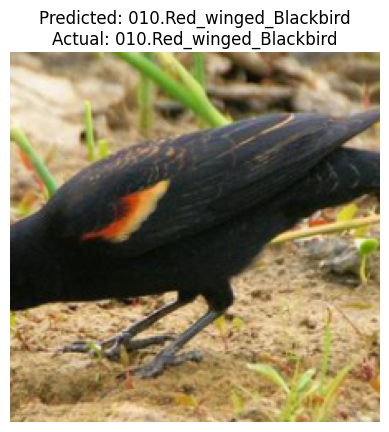

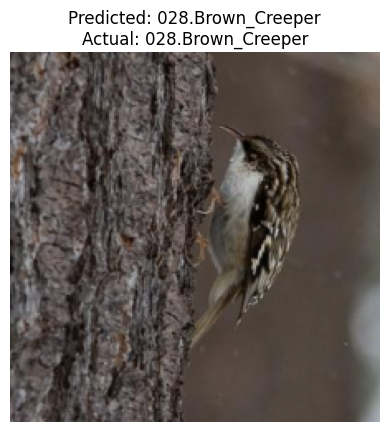

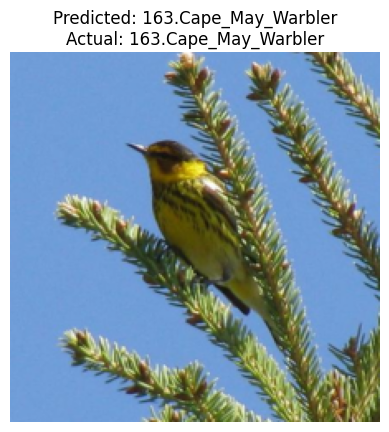

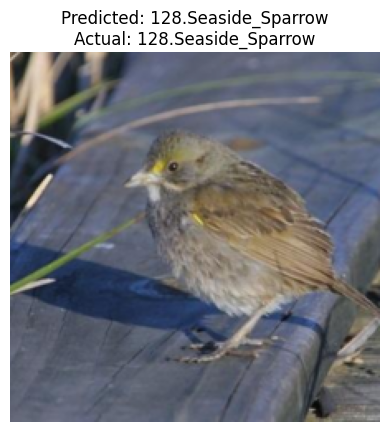

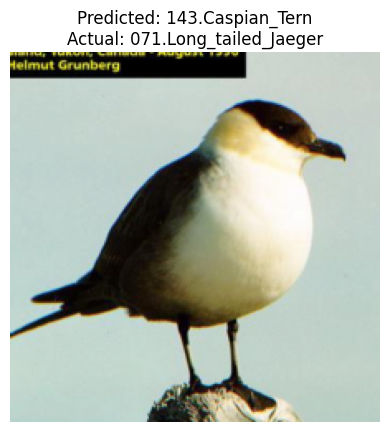

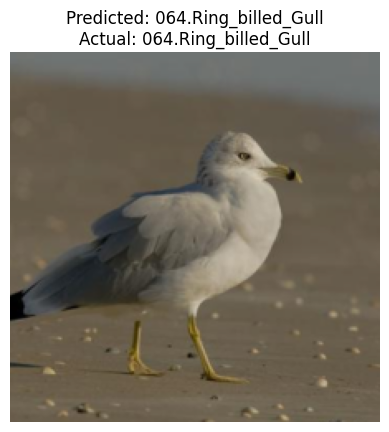

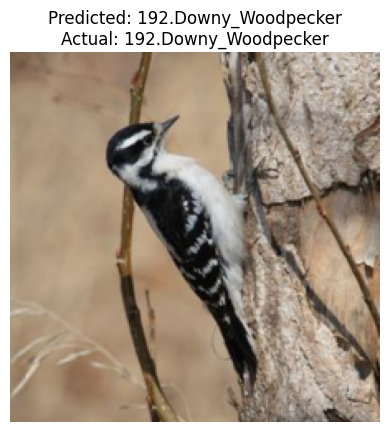

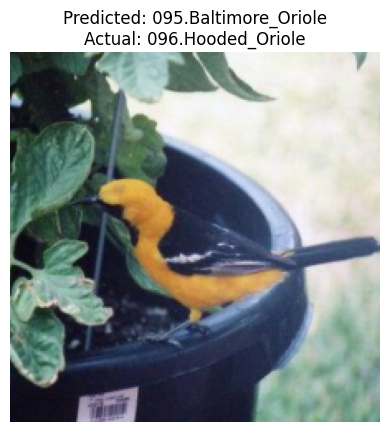

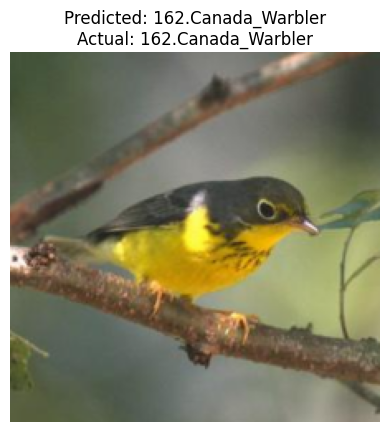

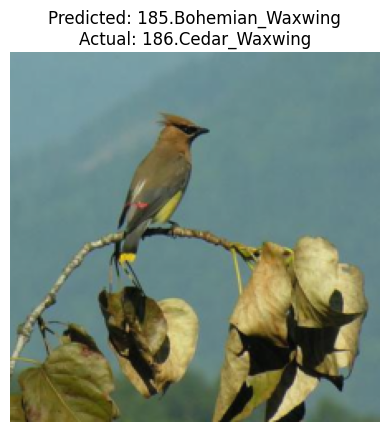

In [28]:
# Prediction simulation

# Function to display the image and predicted label
def show_prediction(image, predicted_label, actual_label):
    # Denormalize the image before displaying
    mean = np.array([0.485, 0.456, 0.406]).reshape((3, 1, 1))
    std = np.array([0.229, 0.224, 0.225]).reshape((3, 1, 1))
    image = image * std + mean
    image = np.clip(image, 0, 1) # Ensure values are within [0, 1] range

    # Map numerical labels to class names
    predicted_class_name = class_names[predicted_label]
    actual_class_name = class_names[actual_label]

    #plt.imshow: display image
    # Transpose the image from (C, H, W) to (H, W, C) for matplotlib
    plt.imshow(image.transpose(1, 2, 0)) # Remove cmap='gray' as it's a color image
    # we turn off the axis so that the displayed image is smoother
    plt.axis("off")
    # We give the predicted label to title
    plt.title(f"Predicted: {predicted_class_name}\nActual: {actual_class_name}")
    plt.show()

# Specify the number of sample images to test
num_samples = 10

# Select random sample images from the test set
sample_indices = np.random.choice(len(image_datasets['test']), num_samples, replace=False)

for index in sample_indices:
    sample_image, sample_label = image_datasets['test'][index]
    sample_image = sample_image.to(device).unsqueeze(0) #because the input model wants our image to be in a format: (Batch, h, w)

    # Make the prediction
    model.eval()# change the mode model to eval
    with torch.no_grad():# this is an operation to lighten our gpu
        output = model(sample_image)# output prediction from model with input sample_img
        _, predicted = torch.max(output.data, 1) # we get the maximum index from torch.max of the prediction result

    # Convert the tensor to a numpy array
    sample_image = sample_image.cpu().squeeze().numpy() # Converting format again B,C,H,W -> C,H,W

    # Display the sample image and predicted label
    show_prediction(sample_image, predicted.item(), sample_label)

We have tested 10 images for prediction simulation. In the simulation, we got 7 correct out of 10 total samples. This result matchs our accuracy score of 70%.

## **Saving models**



In [31]:
# Saving pytorch model
torch.save(model.state_dict(), "model.pth")
print("Saved PyTorch Model State to model.pth")

Saved PyTorch Model State to model.pth


## **Conclusion**

In this tutorial, we successfully implemented a transfer learning approach using the ResNet18 model to classify 200 species of birds from the CUB-200-2011 dataset, achieving an overall average accuracy (per species) of 70.19%.

**Identified areas for improvement**

Further enhancements could be explored by:
*   Unfreezing more layers for fine-tuning to allow the model to learn more task-specific features.
*   Experimenting with different data augmentation strategies to increase the diversity of the training data.
*   Trying more advanced pre-trained architectures (e.g., ResNet50, EfficientNet) that might offer better feature representation capabilities.
*   Addressing species with low classification accuracy, possibly through targeted data collection or specific augmentation techniques for those classes.

## **Resources**

- **PyTorch Documentation**: The official resource for all PyTorch functionalities.
  [https://pytorch.org/docs/stable/index.html](https://pytorch.org/docs/stable/index.html)
- **Torchvision Documentation**: For datasets, models, and transforms in computer vision.
  [https://pytorch.org/vision/stable/index.html](https://pytorch.org/vision/stable/index.html)
- **ResNet Paper**: "Deep Residual Learning for Image Recognition" by He et al.
  [https://arxiv.org/abs/1512.03385](https://arxiv.org/abs/1512.03385)
- **CUB-200-2011 Dataset**: Information about the Caltech-UCSD Birds 200 dataset.
  [http://www.vision.caltech.edu/datasets/CUB_200_2011/](http://www.vision.caltech.edu/datasets/CUB_200_2011/)
- **scikit-learn**: For machine learning metrics like precision, recall, and F1-score.
  [https://scikit-learn.org/stable/](https://scikit-learn.org/stable/)
- **Matplotlib**: For plotting and visualization.
  [https://matplotlib.org/](https://matplotlib.org/)
- **Seaborn**: For enhanced statistical data visualization.
  [https://seaborn.pydata.org/](https://seaborn.pydata.org/)